Base Model 2 : 이상치 제거 없이 클러스터링

In [2]:
import pandas as pd
import numpy as np

In [3]:
df_test = pd.read_csv('test_features.csv')
df_train = pd.read_csv('train_features.csv')
df_valid = pd.read_csv('valid_features.csv')

In [4]:
cluster_feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

X_train_cluster = df_train[cluster_feature_cols].copy()
X_test_cluster = df_test[cluster_feature_cols].copy()
X_valid_cluster = df_valid[cluster_feature_cols].copy()

#무한대 및 이상치 제거
X_train_cluster = X_train_cluster.replace([np.inf, -np.inf], np.nan)
X_train_cluster = X_train_cluster.dropna()

X_test_cluster = X_test_cluster.replace([np.inf, -np.inf], np.nan)
X_test_cluster = X_test_cluster.dropna()

X_valid_cluster = X_valid_cluster.replace([np.inf, -np.inf], np.nan)
X_valid_cluster = X_valid_cluster.dropna()

# X_cluster 인덱스에 맞추기
df_train = df_train.loc[X_train_cluster.index].copy()
df_test = df_test.loc[X_test_cluster.index].copy()
df_valid = df_valid.loc[X_valid_cluster.index].copy()
print(X_train_cluster.shape)
print(X_test_cluster.shape)
print(X_valid_cluster.shape)

(42317, 8)
(3698, 8)
(3716, 8)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_cluster_scaled = scaler.fit_transform(X_train_cluster)
X_test_cluster_scaled = scaler.transform(X_test_cluster)
X_valid_cluster_scaled = scaler.transform(X_valid_cluster)

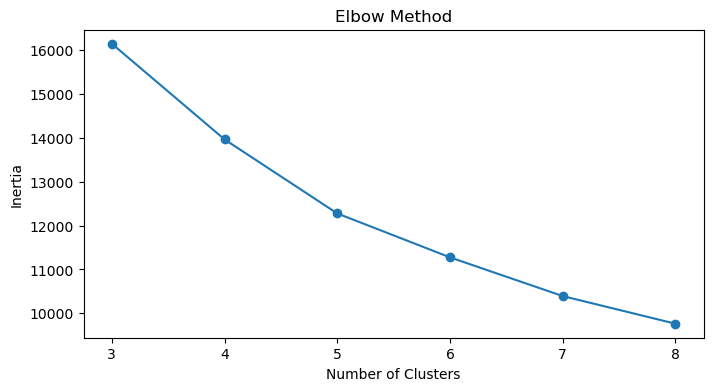

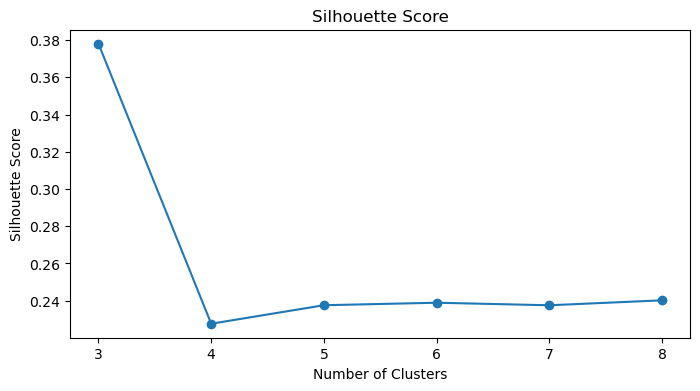

,k,inertia,silhouette
0,3,16151.864715,0.378086
1,4,13967.301764,0.227576
2,5,12277.374982,0.237518
3,6,11275.094732,0.238860
4,7,10391.322795,0.237496
5,8,9760.262681,0.240155


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(3, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_valid_cluster_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_valid_cluster_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

In [17]:
#k=3으로 k-means 진행
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans.fit(X_train_cluster_scaled)

df_test_scaled["cluster"] = kmeans.predict(X_test_cluster_scaled)

df_test_scaled["cluster"].value_counts().sort_index()

cluster
0    3695
1       2
2       1
Name: count, dtype: int64

In [18]:
#베이스 모델의 성능을 시각화를 통해 확인하기 위해 tsne으로 차원 감소 후 산점도로 시각화
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(df_test_scaled[cluster_feature_cols])

In [19]:
df_tsne = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
df_tsne['cluster'] = df_test_scaled['cluster']

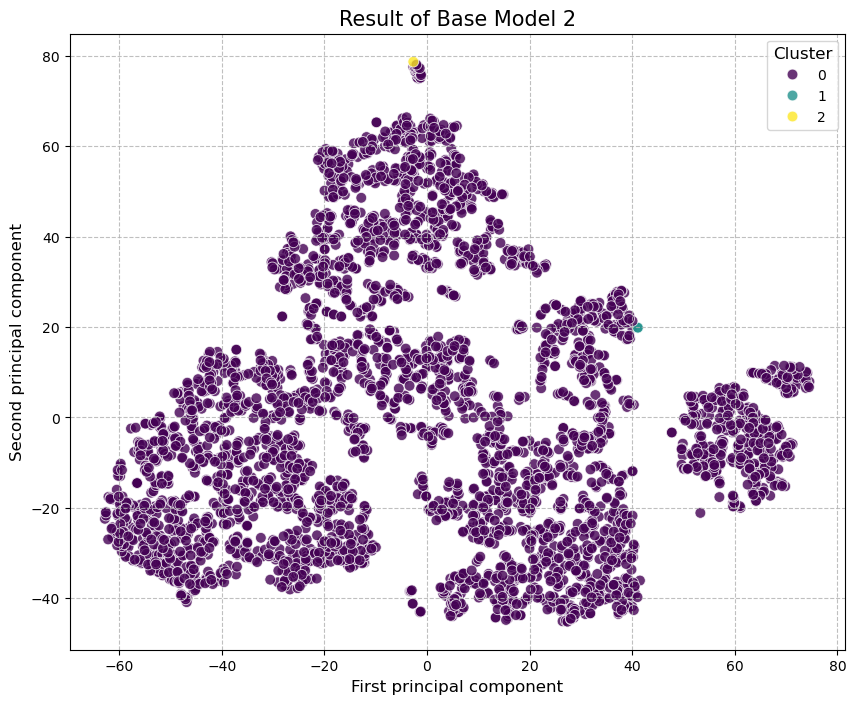

In [20]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='cluster', 
                palette='viridis', s=60, alpha=0.8, edgecolor='w', legend='full')

plt.title('Result of Base Model 2', fontsize=15)
plt.xlabel('First principal component', fontsize=12)
plt.ylabel('Second principal component', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.8)
plt.legend(title='Cluster', title_fontsize=12, fontsize=10)
plt.savefig('base_model2_result.png', dpi=300, bbox_inches="tight")
plt.show()